## Setup

In [1]:
'''Locate the working directory'''
if __name__ == '__main__':    
    import sys
    from _path import workdir
    sys.path.append(workdir)
    print(sys.path[-1])

c:\Users\vince\OneDrive - Montana State University\python projects\py stellar perturbations\test\I_Love_Q\..\..


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from src.util.constants import G, c, msun
from src.static.tov import solve_tov
from src.eos.mmitbag import eos_ccsc
from src.perturb.stationary.rot_gr import bvp_rot
from src.perturb.stationary.love_solid_gr import bvp_love_solid
from src.perturb.empirical.UR_fit import moi_love

from matplotlib.ticker import FormatStrFormatter, LogLocator

## Parameters

In [3]:
rho_list = np.logspace(14.93,15.4,13)
pcut = 1.e20

## Compute background solution and then $k_2$, $I$ and $Q$

The following reproduces Fig. 2 of Lau 2017

Lau 2017:
https://journals.aps.org/prd/abstract/10.1103/PhysRevD.95.101302

In [4]:
'''Initialize EOS'''
eos = eos_ccsc(a4 = 0.8, a2 = 100**2, B = 160**4, gap = 25.)

'''Initialize TOV solver'''
tov=solve_tov(eos)

'''Initialize output arrays'''
m_list = np.empty_like(rho_list)
r_list = np.empty_like(rho_list)
moi_list = np.empty_like(rho_list)
love_list = np.empty_like(rho_list)
Q_list = np.empty_like(rho_list)

for idx, rho in enumerate(rho_list):
    '''Compute background'''
    tov.ivp(p0= eos.p(rho),pcut=pcut)
    m_list[idx] = tov.m[-1]
    r_list[idx] = tov.r[-1]
    '''Compute k2, and then rescaled Love'''
    cal_love = bvp_love_solid(bsol = tov, eos_shear = eos)
    k2 = cal_love.solve_Love()
    love_list[idx] = k2*2./3/(G*m_list[idx]/r_list[idx]/c**2)**5
    '''Compute I, Q, and then the rescaled I, Q'''
    cal_IQ = bvp_rot(bsol = tov)
    moi, _ = cal_IQ.solve_IQ()
    moi_list[idx] = G/c**2*moi/(G*m_list[idx]/c**2)**3

### Plots

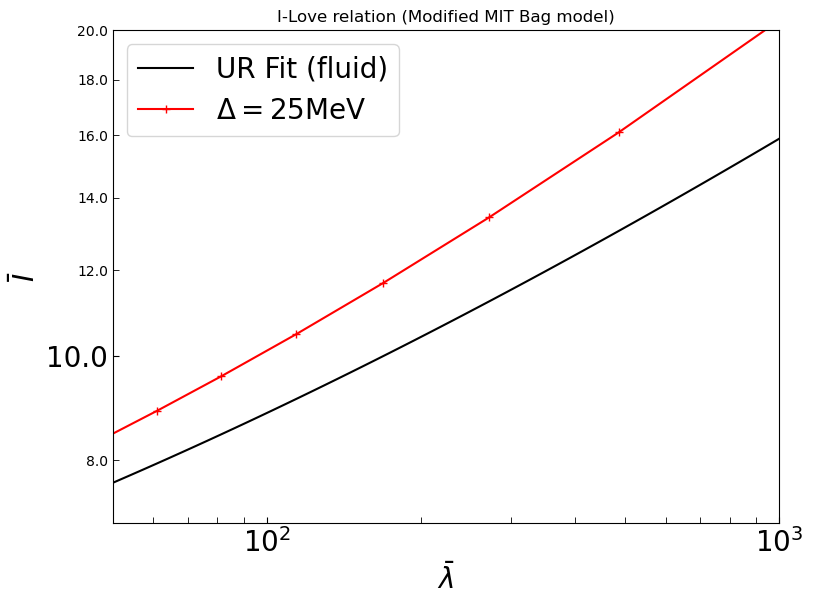

In [5]:
love_fit_list = np.logspace(1.,3.5,100)

plt.figure(figsize=(8.6,6.4), dpi= 100)
plt.plot(love_fit_list, moi_love(love_fit_list), 'k-', label = 'UR Fit (fluid)')
plt.plot(love_list, moi_list, linestyle = 'solid', marker = '+', color = 'red', label = r'$\Delta = 25\text{MeV}$')
plt.title(r'I-Love relation (Modified MIT Bag model)')
plt.xlabel(r'$\bar{\lambda}$',fontsize=20)
plt.ylabel(r'$\bar{I}$',fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xscale('log')
plt.yscale('log')
plt.xlim([50., 1000.])
plt.ylim([7., 20.])
ax = plt.gca()
ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=10))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 20)*0.2, numticks=10))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.yaxis.set_minor_formatter(FormatStrFormatter('%.1f'))
plt.tick_params(direction='in', length=4, which='both')
plt.legend(fontsize=20, frameon = 'True')
plt.show()
plt.close()

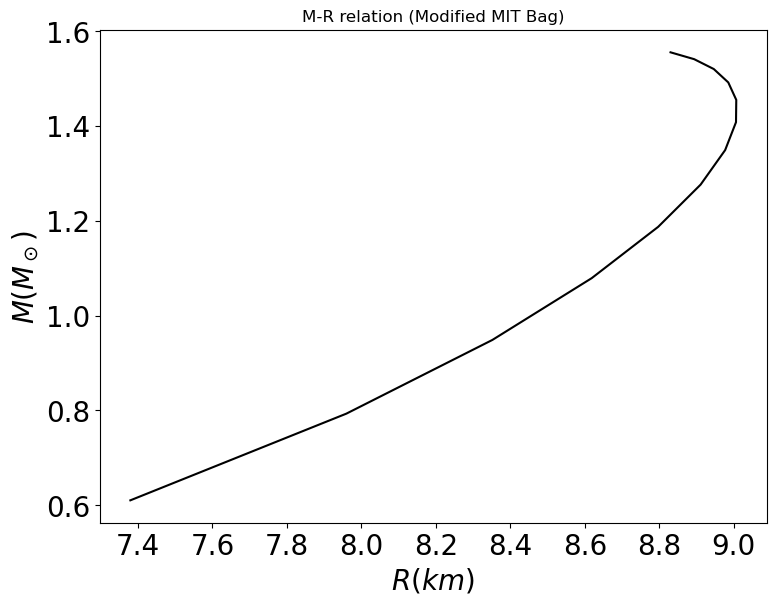

In [6]:
plt.figure(figsize=(8.6,6.4), dpi= 100)
plt.plot(r_list/1.e5, m_list/msun, 'k-')
plt.title(r'M-R relation (Modified MIT Bag)')
plt.xlabel(r'$R (km)$',fontsize=20)
plt.ylabel(r'$M (M_\odot)$',fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()
plt.close()